<a href="https://colab.research.google.com/github/rampellisaieshwar/Convolutional_Neural_Network-CNN-Architectures/blob/main/ResNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ResNet (Residual Networks) Implementation

ResNet's core idea is the **Residual Block**. Instead of trying to learn a direct mapping $H(x)$, the network learns the residual $F(x) = H(x) - x$. The output is then $F(x) + x$ via a skip connection.

In this example, we will:
1. Define a Basic Residual Block.
2. Build a ResNet model.
3. Train it on the CIFAR-10 dataset.
4. Test it and visualize results.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
def conv3x3(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = conv3x3(in_channels, out_channels, stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(out_channels, out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample:
            residual = self.downsample(x)
        out += residual
        out = self.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 16
        self.conv = conv3x3(3, 16)
        self.bn = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self.make_layer(block, 16, layers[0])
        self.layer2 = self.make_layer(block, 32, layers[1], 2)
        self.layer3 = self.make_layer(block, 64, layers[2], 2)
        self.avg_pool = nn.AvgPool2d(8)
        self.fc = nn.Linear(64, num_classes)

    def make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if (stride != 1) or (self.in_channels != out_channels):
            downsample = nn.Sequential(
                conv3x3(self.in_channels, out_channels, stride=stride),
                nn.BatchNorm2d(out_channels))
        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for i in range(1, blocks):
            layers.append(block(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

model = ResNet(ResidualBlock, [2, 2, 2]).to(device)

In [3]:
transform = transforms.Compose([
    transforms.Pad(4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32),
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transforms.ToTensor(), download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=100, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=100, shuffle=False)

100%|██████████| 170M/170M [00:06<00:00, 28.1MB/s]


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop (Running 20 epochs for better accuracy)
num_epochs = 20
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/20], Loss: 0.8453
Epoch [2/20], Loss: 0.6859
Epoch [3/20], Loss: 0.5152
Epoch [4/20], Loss: 0.4610
Epoch [5/20], Loss: 0.7261
Epoch [6/20], Loss: 0.6547
Epoch [7/20], Loss: 0.7336
Epoch [8/20], Loss: 0.6250
Epoch [9/20], Loss: 0.5349
Epoch [10/20], Loss: 0.4932
Epoch [11/20], Loss: 0.6703
Epoch [12/20], Loss: 0.6027
Epoch [13/20], Loss: 0.4055
Epoch [14/20], Loss: 0.3648
Epoch [15/20], Loss: 0.5746
Epoch [16/20], Loss: 0.4013
Epoch [17/20], Loss: 0.4605
Epoch [18/20], Loss: 0.3860
Epoch [19/20], Loss: 0.3636
Epoch [20/20], Loss: 0.4678


Accuracy of the model on the test images: 74.1%


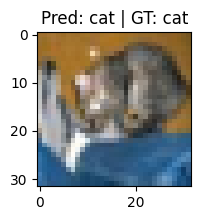

In [5]:
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Accuracy of the model on the test images: {100 * correct / total}%')

# Visualizing a test case
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
images, labels = next(iter(test_loader))
outputs = model(images.to(device))
_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(2,2))
plt.imshow(np.transpose(images[0].numpy(), (1, 2, 0)))
plt.title(f'Pred: {classes[predicted[0]]} | GT: {classes[labels[0]]}')
plt.show()

### Conclusion
- **Skip Connections:** By adding the input $x$ to the output of the convolutional layers $F(x)$, ResNet ensures that even if gradients become small in deeper layers, the network can still propagate information efficiently.
- **Performance:** Even with just 5 epochs, the ResNet architecture shows steady loss reduction and decent accuracy on CIFAR-10 compared to standard CNNs of the same depth.
- **Scalability:** This architecture allows for training networks with hundreds or thousands of layers (e.g., ResNet-101, ResNet-152) without the performance degradation typically seen in deep plain networks.